# Regional AOV Growth Strategy: Sustain and Expand Above $120

## tl;dr

- Transaction-weighted historical AOV is **$125.39**, already above the $120 goal.
- Average customer-level AOV is **$99.95** and median customer AOV is **$84.44**.
- Only **24.5%** of customer records have AOV of at least $120, although they contribute **61.3%** of lifetime spend.
- Active customers average **$119.97** on a customer-level basis, making them the most practical group for raising AOV.
- A scenario that closes 10% of the active below-target gap produces an illustrative active-customer AOV of **$122.40** and **$18.4K** additional next-order revenue.

The scenario is not a time-series forecast. It assumes one next order per active customer and uses historical customer AOV as the order-value proxy.

## Goal and KPI definition

The primary goal is to **keep transaction-weighted AOV above $120 while increasing the share of active customers whose historical AOV is at least $120**.

Three AOV definitions are kept separate:

1. **Transaction-weighted AOV:** total recorded spend divided by total recorded orders.
2. **Average customer AOV:** simple average of each customer record's AOV.
3. **Median customer AOV:** the midpoint customer record.

This distinction prevents a small high-value group from hiding a large below-target customer base.

### 1. Import packages and locate the analysis-ready file

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

COLORS = {
    "blue": "#35648F",
    "gold": "#C89B32",
    "orange": "#CC6B3D",
    "olive": "#7F8C55",
    "ink": "#2F3742",
    "grey": "#AAB4BF",
    "light": "#E7ECF1",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": COLORS["ink"],
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["ink"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "text.color": COLORS["ink"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#D7DCE1",
    "grid.alpha": 0.75,
    "grid.linewidth": 0.8,
})

def find_data_file() -> Path:
    candidates = []
    configured = os.environ.get("CANADA_VAPES_ANALYSIS_FILE")
    if configured:
        candidates.append(Path(configured))
    candidates.extend([
        Path.cwd() / "analysis_ready.csv",
        Path.cwd() / "upload" / "analysis_ready.csv",
        Path("C:/Users/tooko/Downloads/vape/analysis_ready.csv"),
        Path("C:/Users/tooko/Downloads/vape/analysis_ready.csv"),
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    checked = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError("analysis_ready.csv was not found. Checked:\n" + checked)

def money(value: float) -> str:
    return f"${value:,.0f}"

def finish_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

DATA_FILE = find_data_file()
OUTPUT_FOLDER = DATA_FILE.parent / "AOV_120_outputs"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

AOV_GOAL = 120.00
ACTIVE_DAYS = 90

print("Data file:", DATA_FILE)
print("Output folder:", OUTPUT_FOLDER)
print("AOV goal:", f"${AOV_GOAL:,.2f}")

Data file: C:\Users\tooko\Downloads\analysis_ready.csv
Output folder: C:\Users\tooko\Downloads\AOV_120_outputs
AOV goal: $120.00


### 2. Load and validate the customer dataset

In [2]:
required_columns = {
    "customer_record_id", "last_active", "orders", "total_spend", "aov",
    "city", "region", "days_since_last_active", "record_quality_status",
}

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
    parse_dates=["last_active", "sign_up"],
)

missing_columns = sorted(required_columns - set(df.columns))
if missing_columns:
    raise ValueError("Required columns are missing: " + ", ".join(missing_columns))

for column in ["orders", "total_spend", "aov", "days_since_last_active"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["customer_record_id"].duplicated().any():
    raise ValueError("customer_record_id is not unique.")
if df[["orders", "total_spend", "aov", "days_since_last_active"]].isna().any().any():
    raise ValueError("Core analysis fields contain missing or invalid values.")
if (df[["orders", "total_spend", "aov"]].lt(0)).any().any():
    raise ValueError("The analysis-ready dataset contains negative core values.")

snapshot_date = df["last_active"].max().normalize()
df["aov_at_or_above_goal"] = df["aov"].ge(AOV_GOAL)
df["aov_gap_to_goal"] = (AOV_GOAL - df["aov"]).clip(lower=0)
df["is_active"] = df["days_since_last_active"].le(ACTIVE_DAYS)
df["is_repeat_customer"] = df["orders"].ge(2)

print(f"Rows loaded: {len(df):,}")
print(f"Snapshot date: {snapshot_date.date()}")
display(df[[
    "customer_record_id", "orders", "total_spend", "aov", "aov_gap_to_goal",
    "days_since_last_active", "region"
]].head())

Rows loaded: 30,803
Snapshot date: 2026-07-08


,customer_record_id,orders,total_spend,aov,aov_gap_to_goal,days_since_last_active,region
0,CV-000001,11,"1,140.69",103.70,16.30,0,QC
1,CV-000002,54,"8,902.99",164.87,0.00,0,ON
2,CV-000003,18,"2,713.19",150.73,0.00,0,ON
3,CV-000004,2,180.64,90.32,29.68,0,QC
4,CV-000005,49,"6,284.21",128.25,0.00,0,NS


## Company AOV baseline

### 3. Calculate the AOV scorecard

In [3]:
total_spend = float(df["total_spend"].sum())
total_orders = int(df["orders"].sum())
weighted_aov = total_spend / total_orders
mean_customer_aov = float(df["aov"].mean())
median_customer_aov = float(df["aov"].median())
customer_goal_share = float(df["aov_at_or_above_goal"].mean())
goal_customer_spend_share = float(
    df.loc[df["aov_at_or_above_goal"], "total_spend"].sum() / total_spend
)

active_customers = df.loc[df["is_active"]].copy()
active_mean_aov = float(active_customers["aov"].mean())
active_weighted_aov = float(active_customers["total_spend"].sum() / active_customers["orders"].sum())
active_goal_share = float(active_customers["aov_at_or_above_goal"].mean())

aov_scorecard = pd.DataFrame({
    "metric": [
        "Transaction-weighted historical AOV",
        "Average customer AOV",
        "Median customer AOV",
        "Active-customer average AOV",
        "Active transaction-weighted AOV",
        "Customers at or above $120",
        "Spend from customers at or above $120",
    ],
    "value": [
        weighted_aov, mean_customer_aov, median_customer_aov,
        active_mean_aov, active_weighted_aov,
        customer_goal_share, goal_customer_spend_share,
    ],
    "display": [
        f"${weighted_aov:,.2f}", f"${mean_customer_aov:,.2f}",
        f"${median_customer_aov:,.2f}", f"${active_mean_aov:,.2f}",
        f"${active_weighted_aov:,.2f}", f"{customer_goal_share:.1%}",
        f"{goal_customer_spend_share:.1%}",
    ],
})
aov_scorecard.to_csv(OUTPUT_FOLDER / "aov_scorecard.csv", index=False, encoding="utf-8-sig")
display(aov_scorecard[["metric", "display"]])

,metric,display
0,Transaction-weighted historical AOV,$125.39
1,Average customer AOV,$99.95
2,Median customer AOV,$84.44
3,Active-customer average AOV,$119.97
4,Active transaction-weighted AOV,$139.31
5,Customers at or above $120,24.5%
6,Spend from customers at or above $120,61.3%


### 4. Visualize the AOV baseline against the goal

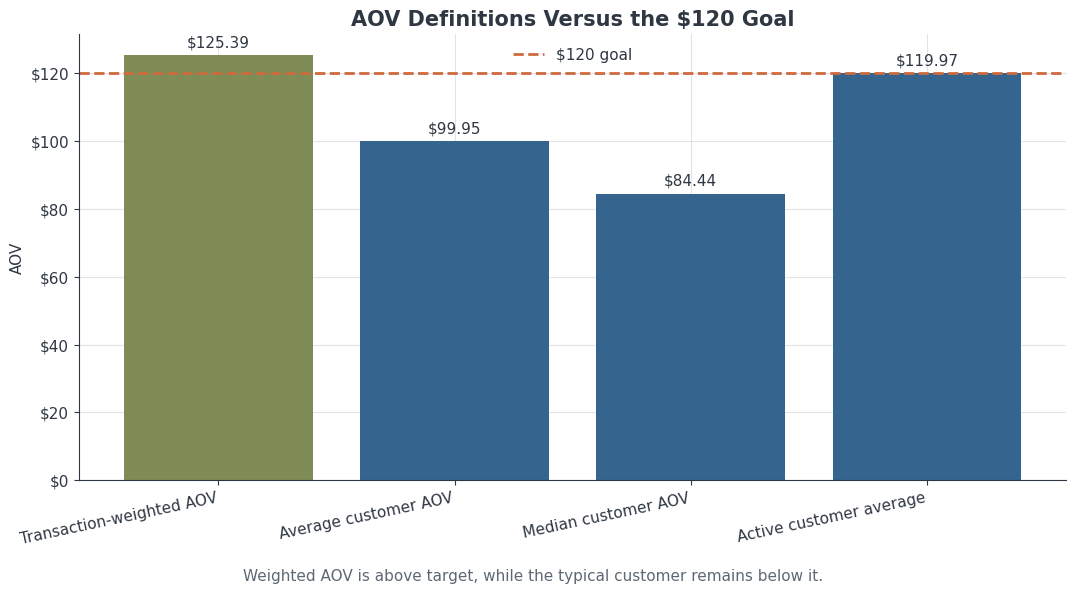

In [4]:
metric_labels = ["Transaction-weighted AOV", "Average customer AOV", "Median customer AOV", "Active customer average"]
metric_values = [weighted_aov, mean_customer_aov, median_customer_aov, active_mean_aov]
metric_colors = [COLORS["olive"] if value >= AOV_GOAL else COLORS["blue"] for value in metric_values]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(metric_labels, metric_values, color=metric_colors)
ax.axhline(AOV_GOAL, color=COLORS["orange"], linestyle="--", linewidth=2, label="$120 goal")
ax.set_title("AOV Definitions Versus the $120 Goal")
ax.set_ylabel("AOV")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.bar_label(bars, labels=[f"${value:,.2f}" for value in metric_values], padding=4)
ax.legend(frameon=False)
finish_axis(ax)
fig.text(0.5, 0.02, "Weighted AOV is above target, while the typical customer remains below it.", ha="center", color="#5E6873")
plt.xticks(rotation=12, ha="right")
plt.tight_layout(rect=[0, 0.05, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "01_aov_scorecard.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Marketing analysis: who should be targeted?

### 5. Create AOV bands and compare customer reach with value

In [5]:
aov_bins = [-np.inf, 60, 90, 120, 150, 200, np.inf]
aov_labels = ["<$60", "$60–89", "$90–119", "$120–149", "$150–199", "$200+"]
df["aov_band"] = pd.cut(df["aov"], bins=aov_bins, labels=aov_labels, right=False)

aov_band_summary = (
    df.groupby("aov_band", observed=True, as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        orders=("orders", "sum"),
        lifetime_spend=("total_spend", "sum"),
        average_aov=("aov", "mean"),
        repeat_rate=("is_repeat_customer", "mean"),
        active_rate=("is_active", "mean"),
    )
)
aov_band_summary["customer_share"] = aov_band_summary["customers"] / len(df)
aov_band_summary["spend_share"] = aov_band_summary["lifetime_spend"] / total_spend
aov_band_summary.to_csv(OUTPUT_FOLDER / "aov_band_summary.csv", index=False, encoding="utf-8-sig")
display(aov_band_summary)

,aov_band,customers,orders,lifetime_spend,average_aov,repeat_rate,active_rate,customer_share,spend_share
0,<$60,5756,11374,"529,780.73",43.91,0.33,0.13,0.19,0.03
1,$60–89,11235,43137,"3,286,770.12",73.63,0.51,0.20,0.36,0.16
2,$90–119,6253,40670,"4,208,943.68",103.13,0.62,0.28,0.20,0.20
3,$120–149,3243,28314,"3,811,498.65",133.65,0.64,0.33,0.11,0.18
4,$150–199,2550,24223,"4,128,807.54",170.79,0.65,0.39,0.08,0.20
5,$200+,1766,17640,"4,769,091.18",274.65,0.68,0.43,0.06,0.23


### 6. Visualize customer share and spend share by AOV band

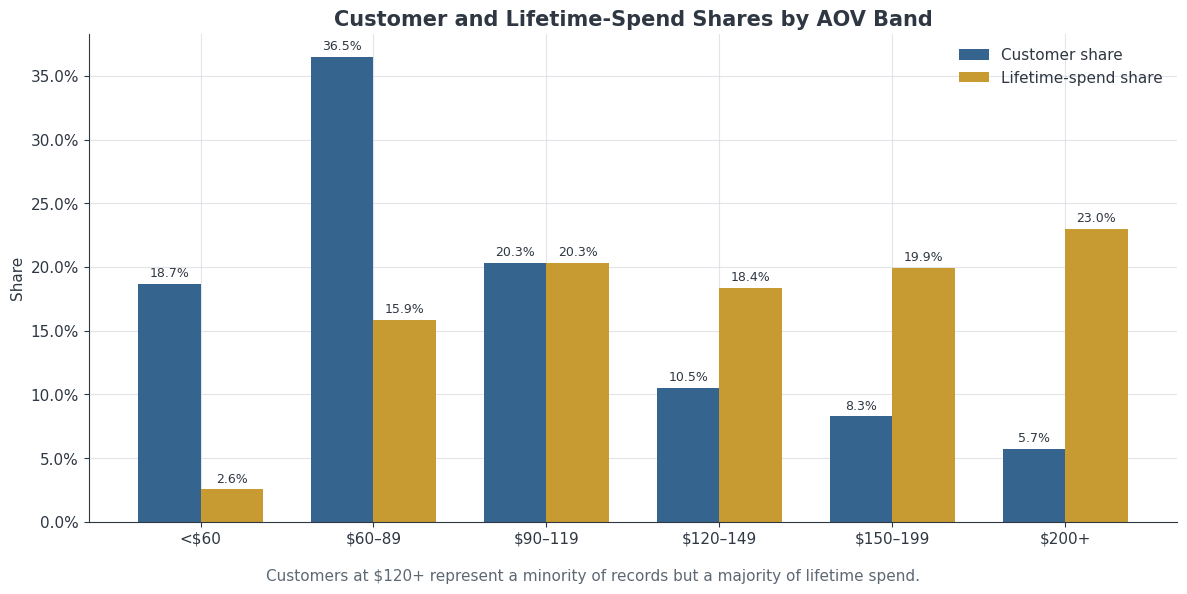

In [6]:
x = np.arange(len(aov_band_summary))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, aov_band_summary["customer_share"], width, label="Customer share", color=COLORS["blue"])
bars2 = ax.bar(x + width/2, aov_band_summary["spend_share"], width, label="Lifetime-spend share", color=COLORS["gold"])
ax.set_xticks(x, aov_band_summary["aov_band"].astype(str))
ax.set_title("Customer and Lifetime-Spend Shares by AOV Band")
ax.set_ylabel("Share")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)
ax.bar_label(bars1, labels=[f"{value:.1%}" for value in aov_band_summary["customer_share"]], padding=3, fontsize=9)
ax.bar_label(bars2, labels=[f"{value:.1%}" for value in aov_band_summary["spend_share"]], padding=3, fontsize=9)
finish_axis(ax)
fig.text(0.5, 0.02, "Customers at $120+ represent a minority of records but a majority of lifetime spend.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.05, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "02_aov_band_customer_and_spend_share.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 7. Build the active below-target marketing groups

In [7]:
active_below_target = df.loc[df["is_active"] & ~df["aov_at_or_above_goal"]].copy()
active_below_target["aov_target_group"] = pd.cut(
    active_below_target["aov"],
    bins=[-np.inf, 80, 100, AOV_GOAL],
    labels=["Large gap (<$80)", "Mid gap ($80–99)", "Near target ($100–119)"],
    right=False,
)

active_gap_summary = (
    active_below_target.groupby("aov_target_group", observed=True, as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        average_aov=("aov", "mean"),
        median_aov=("aov", "median"),
        average_gap=("aov_gap_to_goal", "mean"),
        total_gap=("aov_gap_to_goal", "sum"),
        lifetime_orders=("orders", "sum"),
        lifetime_spend=("total_spend", "sum"),
    )
)

active_below_target.to_csv(OUTPUT_FOLDER / "aov_active_customer_targets.csv", index=False, encoding="utf-8-sig")
active_gap_summary.to_csv(OUTPUT_FOLDER / "aov_active_target_group_summary.csv", index=False, encoding="utf-8-sig")
display(active_gap_summary)

,aov_target_group,customers,average_aov,median_aov,average_gap,total_gap,lifetime_orders,lifetime_spend
0,Large gap (<$80),2173,61.73,66.57,58.27,"126,616.20",11538,"776,522.08"
1,Mid gap ($80–99),1509,89.50,89.58,30.50,"46,018.61",16738,"1,512,197.55"
2,Near target ($100–119),1052,109.22,109.10,10.78,"11,344.41",14171,"1,548,256.98"


### 8. Visualize the active-customer AOV gap

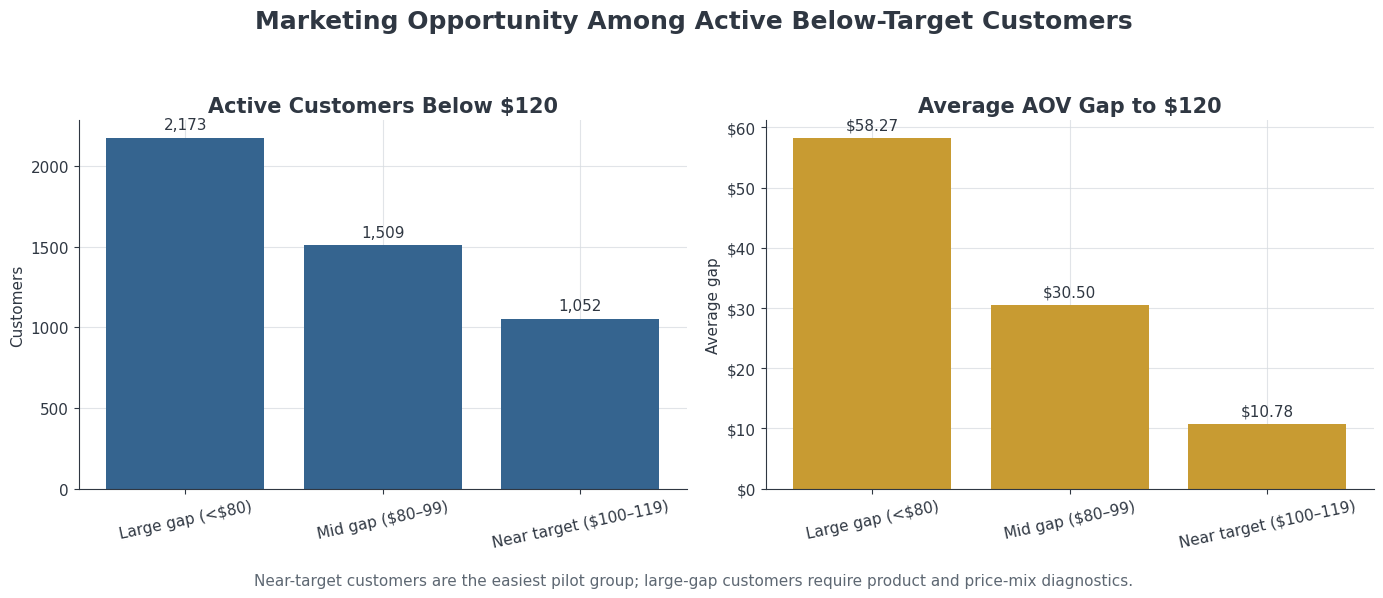

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(active_gap_summary["aov_target_group"].astype(str), active_gap_summary["customers"], color=COLORS["blue"])
axes[0].set_title("Active Customers Below $120")
axes[0].set_ylabel("Customers")
axes[0].bar_label(bars1, labels=[f"{value:,.0f}" for value in active_gap_summary["customers"]], padding=4)
finish_axis(axes[0])

bars2 = axes[1].bar(active_gap_summary["aov_target_group"].astype(str), active_gap_summary["average_gap"], color=COLORS["gold"])
axes[1].set_title("Average AOV Gap to $120")
axes[1].set_ylabel("Average gap")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].bar_label(bars2, labels=[f"${value:,.2f}" for value in active_gap_summary["average_gap"]], padding=4)
finish_axis(axes[1])

fig.suptitle("Marketing Opportunity Among Active Below-Target Customers", fontsize=18, fontweight="bold")
fig.text(0.5, 0.02, "Near-target customers are the easiest pilot group; large-gap customers require product and price-mix diagnostics.", ha="center", color="#5E6873")
for ax in axes:
    ax.tick_params(axis="x", rotation=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
CHART_FILE = OUTPUT_FOLDER / "03_active_customer_gap_groups.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Sales analysis: what behaviors and regions support higher AOV?

### 9. Compare AOV by recorded order-frequency group

In [9]:
frequency_bins = [0, 1, 2, 5, 10, 25, np.inf]
frequency_labels = ["1 order", "2 orders", "3–5 orders", "6–10 orders", "11–25 orders", "26+ orders"]
df["order_frequency_group"] = pd.cut(df["orders"], bins=frequency_bins, labels=frequency_labels)

frequency_summary = (
    df.groupby("order_frequency_group", observed=True, as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        lifetime_orders=("orders", "sum"),
        average_customer_aov=("aov", "mean"),
        median_customer_aov=("aov", "median"),
        goal_share=("aov_at_or_above_goal", "mean"),
    )
)
frequency_summary["weighted_aov"] = frequency_summary["lifetime_spend"] / frequency_summary["lifetime_orders"]
frequency_summary.to_csv(OUTPUT_FOLDER / "aov_order_frequency_summary.csv", index=False, encoding="utf-8-sig")
display(frequency_summary)

,order_frequency_group,customers,lifetime_spend,lifetime_orders,average_customer_aov,median_customer_aov,goal_share,weighted_aov
0,1 order,14474,"1,280,542.47",14474,88.47,73.48,0.18,88.47
1,2 orders,4519,"849,157.71",9038,93.95,79.52,0.20,93.95
2,3–5 orders,4887,"1,819,128.15",18231,99.37,86.87,0.22,99.78
3,6–10 orders,2843,"2,520,305.54",21709,115.33,95.72,0.30,116.09
4,11–25 orders,2687,"5,977,040.11",43674,134.29,115.37,0.47,136.86
5,26+ orders,1393,"8,288,717.92",58232,143.09,129.46,0.58,142.34


### 10. Visualize the relationship between frequency and AOV

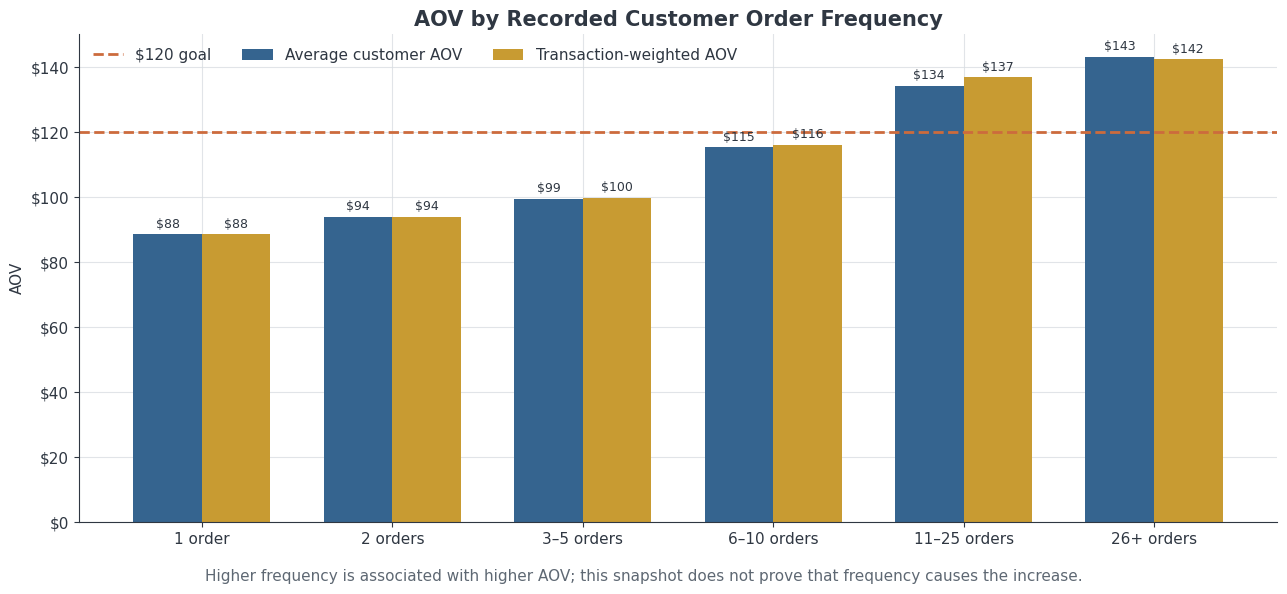

In [10]:
x = np.arange(len(frequency_summary))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, frequency_summary["average_customer_aov"], width, label="Average customer AOV", color=COLORS["blue"])
bars2 = ax.bar(x + width/2, frequency_summary["weighted_aov"], width, label="Transaction-weighted AOV", color=COLORS["gold"])
ax.axhline(AOV_GOAL, color=COLORS["orange"], linestyle="--", linewidth=2, label="$120 goal")
ax.set_xticks(x, frequency_summary["order_frequency_group"].astype(str))
ax.set_title("AOV by Recorded Customer Order Frequency")
ax.set_ylabel("AOV")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.bar_label(bars1, labels=[f"${value:,.0f}" for value in frequency_summary["average_customer_aov"]], padding=3, fontsize=9)
ax.bar_label(bars2, labels=[f"${value:,.0f}" for value in frequency_summary["weighted_aov"]], padding=3, fontsize=9)
finish_axis(ax)
fig.text(0.5, 0.02, "Higher frequency is associated with higher AOV; this snapshot does not prove that frequency causes the increase.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.05, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "04_aov_by_order_frequency.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

### 11. Compare regional AOV performance

In [11]:
region_summary = (
    df.assign(region=df["region"].fillna("Unknown"))
    .groupby("region", as_index=False)
    .agg(
        customers=("customer_record_id", "size"),
        lifetime_spend=("total_spend", "sum"),
        lifetime_orders=("orders", "sum"),
        average_customer_aov=("aov", "mean"),
        goal_share=("aov_at_or_above_goal", "mean"),
        active_share=("is_active", "mean"),
    )
)
region_summary["weighted_aov"] = region_summary["lifetime_spend"] / region_summary["lifetime_orders"]
region_summary = region_summary.sort_values("weighted_aov", ascending=False)
region_summary.to_csv(OUTPUT_FOLDER / "aov_region_summary.csv", index=False, encoding="utf-8-sig")
display(region_summary)

,region,customers,lifetime_spend,lifetime_orders,average_customer_aov,goal_share,active_share,weighted_aov
6,NT,185,"94,114.07",595,129.43,0.42,0.26,158.17
11,SK,564,"436,737.08",2898,112.40,0.30,0.25,150.70
2,MB,574,"372,209.35",2702,99.24,0.23,0.21,137.75
1,BC,4037,"2,268,979.54",16847,104.85,0.27,0.21,134.68
0,AB,2137,"1,191,982.86",8898,94.24,0.22,0.24,133.96
4,NL,495,"239,931.26",1856,97.91,0.23,0.25,129.27
9,PE,594,"435,651.22",3436,105.65,0.30,0.31,126.79
7,NU,92,"32,856.74",260,125.15,0.46,0.25,126.37
10,QC,7914,"5,359,950.08",42742,100.23,0.25,0.26,125.40
8,ON,9026,"6,273,708.00",51326,96.96,0.23,0.22,122.23


### 12. Visualize regional weighted AOV

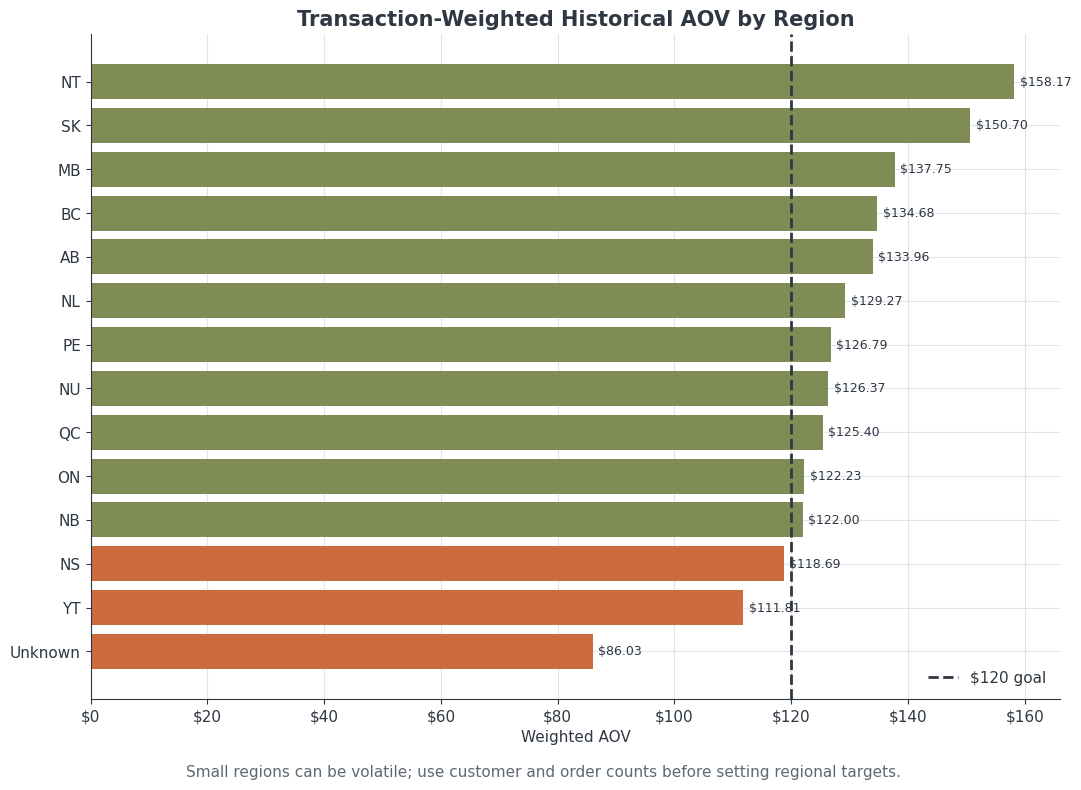

In [12]:
region_plot = region_summary.sort_values("weighted_aov", ascending=True)
colors = [COLORS["olive"] if value >= AOV_GOAL else COLORS["orange"] for value in region_plot["weighted_aov"]]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(region_plot["region"], region_plot["weighted_aov"], color=colors)
ax.axvline(AOV_GOAL, color=COLORS["ink"], linestyle="--", linewidth=2, label="$120 goal")
ax.set_title("Transaction-Weighted Historical AOV by Region")
ax.set_xlabel("Weighted AOV")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
ax.bar_label(bars, labels=[f"${value:,.2f}" for value in region_plot["weighted_aov"]], padding=4, fontsize=9)
ax.legend(frameon=False)
finish_axis(ax)
fig.text(0.5, 0.02, "Small regions can be volatile; use customer and order counts before setting regional targets.", ha="center", color="#5E6873")
plt.tight_layout(rect=[0, 0.04, 1, 1])
CHART_FILE = OUTPUT_FOLDER / "05_region_weighted_aov.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Operations analysis: how should AOV improvement be implemented?

The current file has no cart, product, quantity, discount, shipping-cost or gross-margin fields. Operationally, the company should therefore start with a controlled AOV program and add basket-level measurement before scaling:

1. Display a **$125–$130 threshold** or relevant add-on recommendation so successful orders land above $120 rather than exactly at it.
2. Begin with active customers in the `$100–$119` group, where the average gap is small.
3. Use product-compatible bundles only after SKU-level affinity, margin and stock availability are available.
4. Track gross profit per order, conversion, returns and repeat rate as guardrails; AOV alone can increase while profit falls.

### 13. Build transparent next-order AOV scenarios

In [13]:
active_below_gap_total = float(active_customers["aov_gap_to_goal"].sum())
active_customer_count = len(active_customers)

gap_capture_rates = [0.00, 0.10, 0.25, 0.50]
scenario_names = ["No uplift", "10% gap capture", "25% gap capture", "50% gap capture"]

scenario_rows = []
for scenario_name, capture_rate in zip(scenario_names, gap_capture_rates):
    incremental_revenue = active_below_gap_total * capture_rate
    projected_next_order_pool = float(active_customers["aov"].sum()) + incremental_revenue
    projected_active_aov = projected_next_order_pool / active_customer_count
    scenario_rows.append({
        "scenario": scenario_name,
        "gap_capture_rate": capture_rate,
        "active_customers": active_customer_count,
        "baseline_active_customer_aov": active_mean_aov,
        "projected_active_customer_aov": projected_active_aov,
        "illustrative_incremental_next_order_revenue": incremental_revenue,
        "goal_reached": projected_active_aov >= AOV_GOAL,
    })

aov_scenarios = pd.DataFrame(scenario_rows)
aov_scenarios.to_csv(OUTPUT_FOLDER / "aov_next_order_scenarios.csv", index=False, encoding="utf-8-sig")
display(aov_scenarios)

,scenario,gap_capture_rate,active_customers,baseline_active_customer_aov,projected_active_customer_aov,illustrative_incremental_next_order_revenue,goal_reached
0,No uplift,0.00,7570,119.97,119.97,0.00,False
1,10% gap capture,0.10,7570,119.97,122.40,"18,397.92",True
2,25% gap capture,0.25,7570,119.97,126.05,"45,994.81",True
3,50% gap capture,0.50,7570,119.97,132.12,"91,989.61",True


### 14. Visualize the AOV scenarios and revenue opportunity

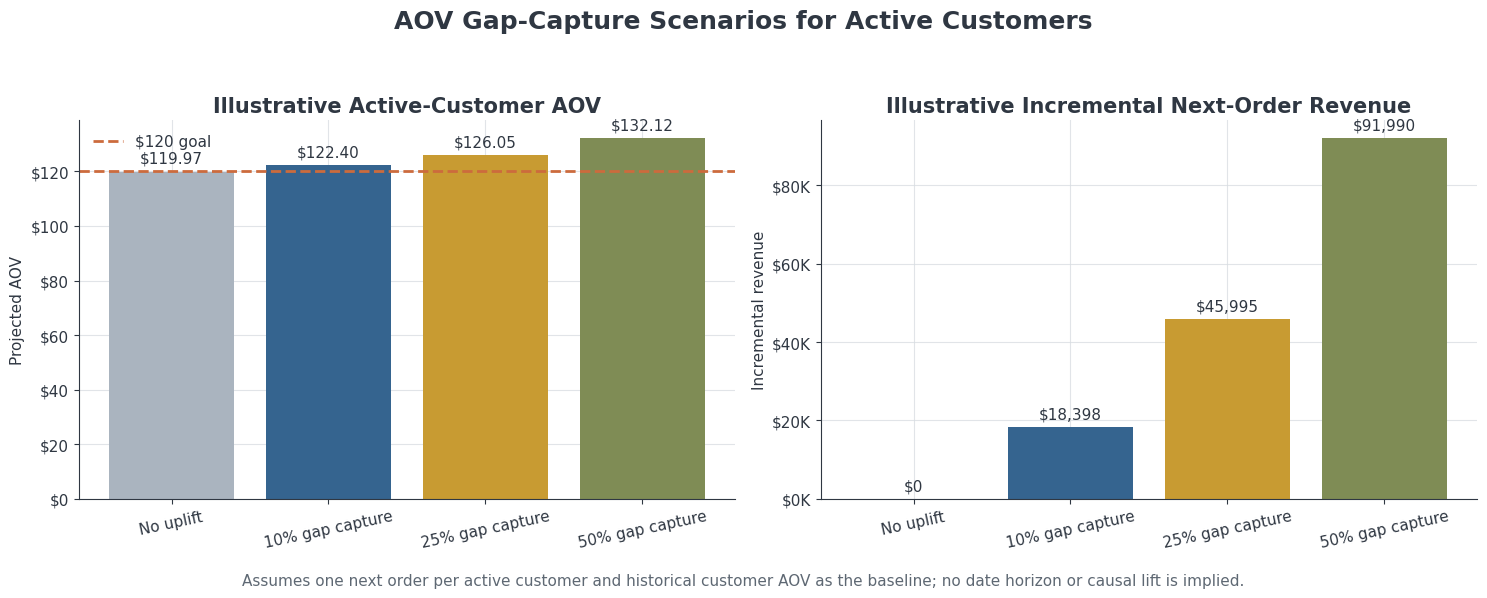

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scenario_colors = [COLORS["grey"]] + [COLORS["blue"], COLORS["gold"], COLORS["olive"]]
bars1 = axes[0].bar(aov_scenarios["scenario"], aov_scenarios["projected_active_customer_aov"], color=scenario_colors)
axes[0].axhline(AOV_GOAL, color=COLORS["orange"], linestyle="--", linewidth=2, label="$120 goal")
axes[0].set_title("Illustrative Active-Customer AOV")
axes[0].set_ylabel("Projected AOV")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}"))
axes[0].bar_label(bars1, labels=[f"${value:,.2f}" for value in aov_scenarios["projected_active_customer_aov"]], padding=4)
axes[0].legend(frameon=False)
finish_axis(axes[0])

bars2 = axes[1].bar(aov_scenarios["scenario"], aov_scenarios["illustrative_incremental_next_order_revenue"], color=scenario_colors)
axes[1].set_title("Illustrative Incremental Next-Order Revenue")
axes[1].set_ylabel("Incremental revenue")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value/1_000:.0f}K"))
axes[1].bar_label(bars2, labels=[money(value) for value in aov_scenarios["illustrative_incremental_next_order_revenue"]], padding=4)
finish_axis(axes[1])

fig.suptitle("AOV Gap-Capture Scenarios for Active Customers", fontsize=18, fontweight="bold")
fig.text(0.5, 0.02, "Assumes one next order per active customer and historical customer AOV as the baseline; no date horizon or causal lift is implied.", ha="center", color="#5E6873")
for ax in axes:
    ax.tick_params(axis="x", rotation=12)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
CHART_FILE = OUTPUT_FOLDER / "06_aov_scenario_projection.png"
fig.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Strategic recommendations

In [15]:
near_target_count = int(active_gap_summary.loc[
    active_gap_summary["aov_target_group"].astype(str).eq("Near target ($100–119)"), "customers"
].iloc[0])
near_target_gap = float(active_gap_summary.loc[
    active_gap_summary["aov_target_group"].astype(str).eq("Near target ($100–119)"), "average_gap"
].iloc[0])

high_frequency_aov = float(frequency_summary.loc[
    frequency_summary["order_frequency_group"].astype(str).eq("26+ orders"), "weighted_aov"
].iloc[0])

base_scenario = aov_scenarios.loc[aov_scenarios["scenario"].eq("10% gap capture")].iloc[0]

recommendations = pd.DataFrame([
    {
        "priority": 1,
        "analysis_area": "Company KPI",
        "recommendation": "Track weighted AOV and customer-level AOV together",
        "evidence": f"Weighted AOV is ${weighted_aov:,.2f}, but average customer AOV is ${mean_customer_aov:,.2f} and only {customer_goal_share:.1%} of customers reach $120.",
        "success_measure": "Weighted AOV >$120; active-customer mean AOV >$120; gross profit per order does not fall",
    },
    {
        "priority": 2,
        "analysis_area": "Marketing",
        "recommendation": "Pilot add-on and threshold messaging with active near-target customers",
        "evidence": f"{near_target_count:,} active customers average only ${near_target_gap:,.2f} below the $120 goal.",
        "success_measure": "Incremental AOV, conversion and gross profit versus a 10–20% holdout",
    },
    {
        "priority": 3,
        "analysis_area": "Sales",
        "recommendation": "Make repeat conversion and loyalty part of the AOV strategy",
        "evidence": f"Customers with 26+ recorded orders have transaction-weighted AOV of ${high_frequency_aov:,.2f}; one-order customers average below $90.",
        "success_measure": "First-to-second-purchase conversion and AOV by frequency cohort",
    },
    {
        "priority": 4,
        "analysis_area": "Operations",
        "recommendation": "Set checkout thresholds above $120 and protect margin",
        "evidence": "A $125–$130 threshold creates room above the goal, but basket, margin and shipping data are unavailable.",
        "success_measure": "Gross profit per order, items per order, discount cost, fulfillment cost and return rate",
    },
    {
        "priority": 5,
        "analysis_area": "Scenario planning",
        "recommendation": "Use the 10% gap-capture case as the first planning benchmark",
        "evidence": f"It produces illustrative active-customer AOV of ${base_scenario['projected_active_customer_aov']:,.2f} and {money(base_scenario['illustrative_incremental_next_order_revenue'])} next-order revenue.",
        "success_measure": "Validate with a randomized test before treating the scenario as forecastable lift",
    },
])
recommendations.to_csv(OUTPUT_FOLDER / "aov_strategic_recommendations.csv", index=False, encoding="utf-8-sig")
display(recommendations)

,priority,analysis_area,recommendation,evidence,success_measure
0,1,Company KPI,Track weighted AOV and customer-level AOV toge...,"Weighted AOV is $125.39, but average customer ...",Weighted AOV >$120; active-customer mean AOV >...
1,2,Marketing,Pilot add-on and threshold messaging with acti...,"1,052 active customers average only $10.78 bel...","Incremental AOV, conversion and gross profit v..."
2,3,Sales,Make repeat conversion and loyalty part of the...,Customers with 26+ recorded orders have transa...,First-to-second-purchase conversion and AOV by...
3,4,Operations,Set checkout thresholds above $120 and protect...,A $125–$130 threshold creates room above the g...,"Gross profit per order, items per order, disco..."
4,5,Scenario planning,Use the 10% gap-capture case as the first plan...,It produces illustrative active-customer AOV o...,Validate with a randomized test before treatin...


## Forecast and data limitations

A formal future AOV forecast cannot be estimated reliably from this customer snapshot because it contains no dated order-level values. The scenario above is a planning bridge, not a time-series forecast.

For a defensible weekly or monthly forecast, add:

- order date and order value;
- product/SKU, category, price and quantity;
- discount, coupon and shipping revenue;
- product cost, fulfillment cost and gross profit;
- refund/return status;
- acquisition channel and campaign assignment; and
- inventory availability and stockout events.

With those fields, forecast total sales as `forecast orders × forecast AOV`, model seasonality, and test which product and threshold interventions create incremental profit.

### 15. Validate calculations and saved outputs

In [16]:
assert np.isclose(weighted_aov, total_spend / total_orders)
assert int(aov_band_summary["customers"].sum()) == len(df)
assert int(frequency_summary["customers"].sum()) == len(df)
assert int(region_summary["customers"].sum()) == len(df)
assert len(active_below_target) == int((df["is_active"] & ~df["aov_at_or_above_goal"]).sum())
assert aov_scenarios["projected_active_customer_aov"].is_monotonic_increasing
assert aov_scenarios.loc[aov_scenarios["scenario"].eq("10% gap capture"), "goal_reached"].iloc[0]

required_outputs = [
    "aov_scorecard.csv", "aov_band_summary.csv", "aov_active_customer_targets.csv",
    "aov_order_frequency_summary.csv", "aov_region_summary.csv",
    "aov_next_order_scenarios.csv", "aov_strategic_recommendations.csv",
]
for filename in required_outputs:
    assert (OUTPUT_FOLDER / filename).exists(), filename

validation = pd.DataFrame({
    "check": [
        "Weighted AOV reconciliation", "AOV band reconciliation",
        "Frequency reconciliation", "Regional reconciliation",
        "Target-list reconciliation", "10% scenario reaches goal",
        "Required outputs saved",
    ],
    "result": ["Passed"] * 7,
})
display(validation)

,check,result
0,Weighted AOV reconciliation,Passed
1,AOV band reconciliation,Passed
2,Frequency reconciliation,Passed
3,Regional reconciliation,Passed
4,Target-list reconciliation,Passed
5,10% scenario reaches goal,Passed
6,Required outputs saved,Passed
